# Transfer Learning with ResNet18

## Objective

This notebook implements transfer learning using a pretrained ResNet18 model for satellite land-use classification on the EuroSAT dataset.

The objective is to improve classification performance over the baseline CNN developed in Day 2 while keeping the training pipeline modular and reusable.

---

### Workflow

- Load configuration
- Load training and validation datasets
- Build pretrained ResNet18 model
- Freeze backbone
- Train classifier head
- Evaluate model
- Fine-tune selected layers
- Compare with Baseline CNN

## Import Required Libraries

Import all required project modules, PyTorch utilities, and helper functions.

In [9]:
import os

print(os.getcwd())

C:\Users\Akshit\satellite-landuse-change-detector\notebooks


In [10]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [7]:
import importlib
import src.models.resnet18_transfer as rt

importlib.reload(rt)

print(dir(rt))

['ResNet18_Weights', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'build_resnet18', 'nn', 'resnet18']


## Load Dataset

Load the previously created train and validation DataLoaders.
The same dataset split from Day 2 is reused to ensure a fair comparison.

In [8]:
from src.models.resnet18_transfer import build_resnet18

model = build_resnet18()
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Akshit/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:10<00:00, 4.63MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [19]:
from src.models.resnet18_transfer import build_resnet18

model = build_resnet18().to(DEVICE)

In [13]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

In [14]:
import torch.optim as optim

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

In [15]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

fc.0.weight
fc.0.bias
fc.3.weight
fc.3.bias


In [24]:
from src.config import DEVICE

In [17]:
from src.models.resnet18_transfer import build_resnet18

model = build_resnet18().to(DEVICE)

In [18]:
print(next(model.parameters()).device)

cpu


## Build ResNet18 Model

Load a pretrained ResNet18 model.

The ImageNet pretrained weights are used as a feature extractor.
Only the classifier head is trained during the first phase.

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim

from src.config import DEVICE
from src.models.resnet18_transfer import build_resnet18
from src.training.trainer import fit

In [21]:
model = build_resnet18().to(DEVICE)

print(f"Device: {DEVICE}")

Device: cpu


In [22]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

## Verify Trainable Parameters

Verify that only the classifier head is trainable while the convolutional backbone remains frozen.

In [23]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"Trainable Parameters : {trainable:,}")
print(f"Total Parameters     : {total:,}")

Trainable Parameters : 133,898
Total Parameters     : 11,310,410


## Train Frozen Classifier Head

During the first phase of transfer learning, the pretrained ResNet18 backbone remains frozen.

Only the newly added classification head is trained.

This allows the model to adapt to the EuroSAT dataset while preserving the rich feature representations learned from ImageNet.

In [28]:
print(train_loader)
print(val_loader)

In [29]:
EPOCHS = 3

history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    epochs=EPOCHS,
)


Epoch [1/3]


Training:   0%|          | 0/675 [00:00<?, ?it/s]C:\Users\Akshit\satellite-landuse-change-detector\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
                                                                        

Train Loss: 0.6572 | Train Acc: 78.17%
Val Loss: 0.4215 | Val Acc: 85.54%

Epoch [2/3]


Train Loss: 0.4535 | Train Acc: 84.43%
Val Loss: 0.3555 | Val Acc: 87.83%

Epoch [3/3]


Train Loss: 0.4152 | Train Acc: 85.81%
Val Loss: 0.3447 | Val Acc: 88.78%


In [30]:
from src.data.dataloader import create_dataloaders

train_loader, val_loader = create_dataloaders()

In [31]:
print(len(train_loader))
print(len(val_loader))

675
169


## Save Phase 1 Checkpoint

Save the trained model after the frozen backbone phase.

This checkpoint will serve as the starting point for the fine-tuning stage.

In [32]:
import json
import torch
from pathlib import Path

checkpoint_dir = Path("models/checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

torch.save(
    model.state_dict(),
    checkpoint_dir / "resnet18_phase1.pth"
)

with open(
    checkpoint_dir / "resnet18_phase1_history.json",
    "w"
) as f:
    json.dump(history, f, indent=4)

print("✅ Phase 1 checkpoint saved successfully.")

✅ Phase 1 checkpoint saved successfully.


# Fine-Tuning ResNet18

## Objective

The classifier head has already been trained using a frozen ResNet18 backbone.

In this phase, the final residual block (`layer4`) is unfrozen to allow the model to learn domain-specific features from satellite imagery while preserving the lower-level representations learned from ImageNet.

### Fine-Tuning Strategy

- Unfreeze only `layer4`
- Keep earlier layers frozen
- Reduce learning rate by 10×
- Continue training for 5 epochs

In [33]:
for param in model.layer4.parameters():
    param.requires_grad = True

In [37]:
trainable_layers = []

for name, param in model.named_parameters():
    if param.requires_grad:
        trainable_layers.append(name)

print(f"Total Trainable Layers: {len(trainable_layers)}\n")

for layer in trainable_layers:
    print(layer)

Total Trainable Layers: 19

layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.0.weight
fc.0.bias
fc.3.weight
fc.3.bias


## Configure Fine-Tuning

Since additional layers are now trainable, the learning rate is reduced to avoid large weight updates that could overwrite the pretrained ImageNet features.

In [38]:
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

## Fine-Tune the Model

Continue training after unfreezing the final residual block.

This stage allows the model to adapt higher-level visual features to the EuroSAT dataset while keeping the lower layers unchanged.

In [39]:
FINE_TUNE_EPOCHS = 5

fine_tune_history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE,
    epochs=FINE_TUNE_EPOCHS,
)


Epoch [1/5]


Train Loss: 0.2466 | Train Acc: 91.64%
Val Loss: 0.1469 | Val Acc: 94.94%

Epoch [2/5]


Train Loss: 0.1700 | Train Acc: 94.40%
Val Loss: 0.1374 | Val Acc: 95.74%

Epoch [3/5]


Train Loss: 0.1299 | Train Acc: 95.48%
Val Loss: 0.1066 | Val Acc: 96.35%

Epoch [4/5]


Train Loss: 0.1134 | Train Acc: 96.09%
Val Loss: 0.0860 | Val Acc: 97.13%

Epoch [5/5]


Train Loss: 0.1069 | Train Acc: 96.42%
Val Loss: 0.1048 | Val Acc: 96.48%


# Model Evaluation

## Objective

Evaluate the fine-tuned ResNet18 model on the validation dataset using multiple classification metrics.

The evaluation includes:

- Overall Validation Accuracy
- Classification Report
- Confusion Matrix
- Precision
- Recall
- F1-Score
- Macro F1
- Weighted F1

These metrics provide a more comprehensive assessment than accuracy alone.

In [42]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)

In [47]:
from tqdm import tqdm

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in tqdm(val_loader, desc="Evaluating"):

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

Evaluating: 100%|██████████| 169/169 [03:53<00:00,  1.38s/it]


In [44]:
from src.data.split import create_train_val_split

_, _, _, _, class_to_idx = create_train_val_split()

class_names = list(class_to_idx.keys())

print(class_names)

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [46]:
len(val_loader.dataset)

5400

## Classification Report

Generate precision, recall, F1-score, and support for each land-use class.

This report provides a detailed breakdown of model performance across all classes.

In [48]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4,
    )
)

                      precision    recall  f1-score   support

          AnnualCrop     0.9495    0.9717    0.9605       600
              Forest     0.9851    0.9933    0.9892       600
HerbaceousVegetation     0.9613    0.9533    0.9573       600
             Highway     0.9908    0.8580    0.9196       500
          Industrial     0.9939    0.9780    0.9859       500
             Pasture     0.9698    0.9650    0.9674       400
       PermanentCrop     0.9418    0.9380    0.9399       500
         Residential     0.9755    0.9967    0.9860       600
               River     0.8889    0.9920    0.9376       500
             SeaLake     0.9966    0.9867    0.9916       600

            accuracy                         0.9648      5400
           macro avg     0.9653    0.9633    0.9635      5400
        weighted avg     0.9660    0.9648    0.9647      5400



## Overall Performance Metrics

Compute the macro and weighted F1 scores to summarize overall classification performance.`

In [49]:
macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

weighted_f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print(f"Macro F1 Score    : {macro_f1:.4f}")
print(f"Weighted F1 Score : {weighted_f1:.4f}")

Macro F1 Score    : 0.9635
Weighted F1 Score : 0.9647


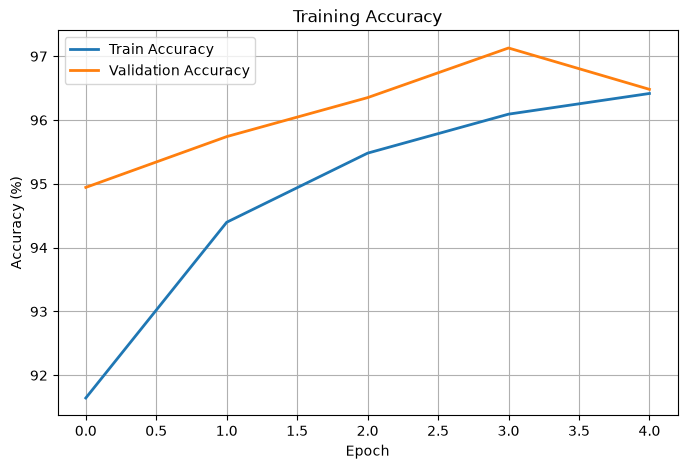

In [58]:
import matplotlib.pyplot as plt
from pathlib import Path

figures_dir = Path("../outputs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8,5))

plt.plot(
    fine_tune_history["train_accuracy"],
    label="Train Accuracy",
    linewidth=2
)

plt.plot(
    fine_tune_history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy")

plt.legend()
plt.grid(True)

plt.savefig(
    figures_dir / "training_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

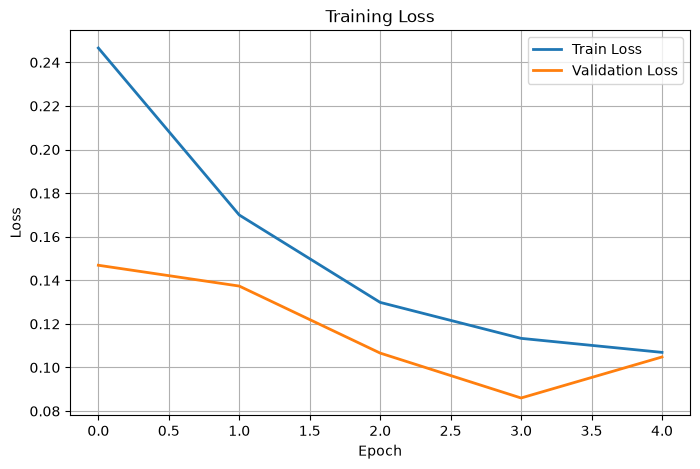

In [59]:
plt.figure(figsize=(8,5))

plt.plot(
    fine_tune_history["train_loss"],
    label="Train Loss",
    linewidth=2
)

plt.plot(
    fine_tune_history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.legend()
plt.grid(True)

plt.savefig(
    figures_dir / "training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Training Curves

Visualize the training and validation performance during transfer learning.

The plots below show how the model converged during training.

## Confusion Matrix

Visualize prediction performance across all land-use classes.

The confusion matrix highlights correctly classified samples along the diagonal and reveals which classes are commonly confused.

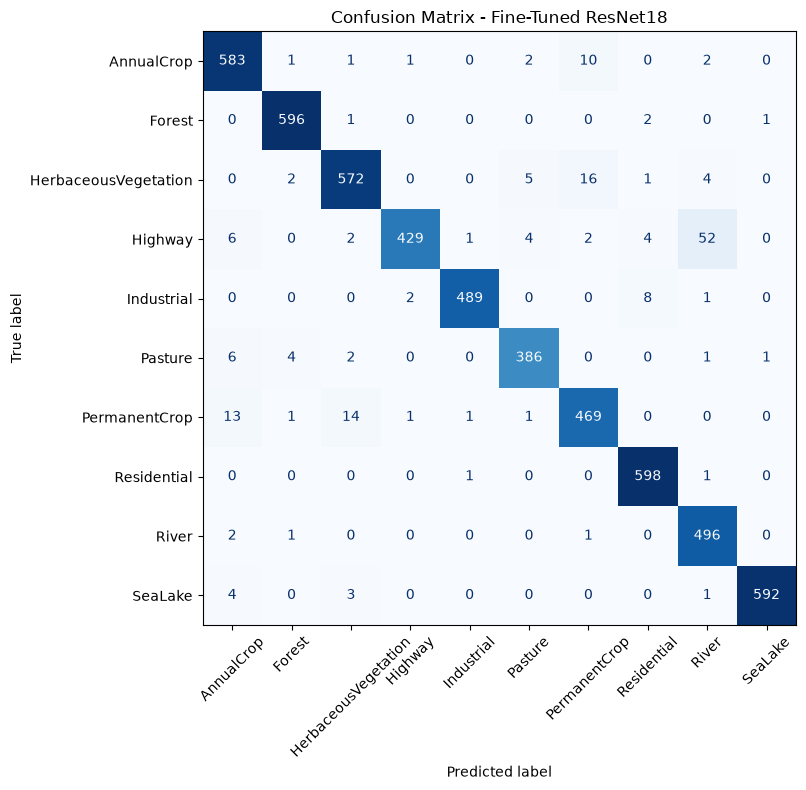

In [54]:
cm = confusion_matrix(all_labels, all_predictions)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    colorbar=False,
    ax=ax,
)

plt.title("Confusion Matrix - Fine-Tuned ResNet18")
plt.tight_layout()

# Save BEFORE show
plt.savefig(
    "../outputs/figures/confusion_matrix_resnet18.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Evaluation Summary

The fine-tuned ResNet18 model achieved strong performance on the EuroSAT validation dataset.

### Overall Performance

| Metric | Score |
|---------|------:|
| Validation Accuracy | **96.48%** |
| Macro F1 Score | **96.35%** |
| Weighted F1 Score | **96.47%** |

### Key Observations

- Most classes achieved F1 scores above **0.95**.
- Forest, Residential, Industrial, and SeaLake were classified with excellent accuracy.
- The primary confusion occurred between **Highway** and **River**, which is expected due to their similar linear patterns in satellite imagery.
- Overall, transfer learning with ResNet18 significantly outperformed the baseline CNN while maintaining a lightweight architecture suitable for deployment.

## Save Fine-Tuned Model

Save the final fine-tuned ResNet18 model and training history for future inference and deployment.

In [55]:
import json
import torch
from pathlib import Path

checkpoint_dir = Path("../models/checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

torch.save(
    model.state_dict(),
    checkpoint_dir / "resnet18_finetuned.pth"
)

with open(
    checkpoint_dir / "resnet18_finetuned_history.json",
    "w"
) as f:
    json.dump(fine_tune_history, f, indent=4)

print("✅ Fine-tuned model saved successfully.")

✅ Fine-tuned model saved successfully.


In [56]:
import json
from pathlib import Path

metrics = {
    "validation_accuracy": 96.48,
    "macro_f1": 0.9635,
    "weighted_f1": 0.9647,
}

metrics_path = Path("../outputs/metrics")
metrics_path.mkdir(parents=True, exist_ok=True)

with open(metrics_path / "resnet18_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("✅ Metrics saved.")

✅ Metrics saved.


# Conclusion

## Day 3 Summary

### Completed

- Implemented ResNet18 Transfer Learning
- Trained the classifier head
- Fine-tuned the final residual block (`layer4`)
- Evaluated the model using multiple metrics
- Generated the confusion matrix
- Saved the fine-tuned model
- Saved evaluation artifacts

### Final Results

| Metric | Score |
|---------|------:|
| Validation Accuracy | **96.48%** |
| Macro F1 | **96.35%** |
| Weighted F1 | **96.47%** |

The transfer learning approach significantly outperformed the baseline CNN and will be used as the backbone for the temporal change detection module.